In [2]:
# === Standard Libraries ===
import os
import numpy as np
import pandas as pd
import scipy
from scipy.stats import median_abs_deviation
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tqdm import tqdm
import pyBigWig as pbw
import logging
logging.getLogger().setLevel(logging.INFO)

# === PyTorch ===
import torch
from torch.utils.data import DataLoader

# === Tangermeme
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise
from tangermeme.io import read_meme
from tangermeme.annotate import annotate_seqlets, count_annotations
from tangermeme.seqlet import recursive_seqlets, tfmodisco_seqlets

# === Vinson Package ===
from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.io import SamplesDensityExtractor
from vinson.utils import intervals_to_ohe
from vinson.models.helpers import _Exp
from vinson.datasets.sequence import SequenceEmbedDataset
from vinson.loss import poisson_loss, mse_loss
from vinson.models.sequence import BassetTrunkEmbed, CellEmbedding, EmbedModel

# === Genome Tools ===
from genome_tools import GenomicInterval
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

# === Plotting ===
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]



/home/mbrannon/.local/miniconda3/envs/tangermeme/lib/python3.8/site-packages/tangermeme/ersatz.py:475: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(params, nopython=False, cache=True)


In [ ]:
#run prediction code -> sbatch predict.sh
#outputs should be
#chrom	mid	embedding_id	predicted_counts	target_counts
#chr22	tensor(16601530)	AG10697	82.31743432418034	11.067932097548955

In [ ]:
#pearson plot is in Correlation_plots notebook

In [549]:
#file comes from vinsion predict.py
headers = [
    "chrom",
    "mid",
    "embedding_id",
    "predicted_counts",
    "target_counts",
    "pred_total_density",
    "obs_total_density"
]
df = pd.read_table('/home/mbrannon/tmp/preds/AUG3_with_warmup_and_decay_prediction_merged.tsv',sep="\t", header=None, names=headers)
#convert from tensor
df["mid"] = df["mid"].astype(str).str.replace(r"tensor\(|\)", "", regex=True).astype(int)


In [550]:
# Apply log transformation (handles 0s safely)
df["log_pred_total_density"] = np.log(df["pred_total_density"]+1e6)
df["log_obs_total_density"] = np.log(df["obs_total_density"]+1e6)

In [551]:
rep_embed = pd.read_table('/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/representative_samples_by_annotation_stratified.tsv')

ag_want = rep_embed[rep_embed['extended_annotation'] == 'Erythroid'].sample_id.values


In [552]:
df_ery = df[df['embedding_id'].isin(ag_want)]

In [553]:
df_ery

,chrom,mid,embedding_id,predicted_counts,target_counts,pred_total_density,obs_total_density,log_pred_total_density,log_obs_total_density
104,chr22,15628403,AG96101,30.680086,21.000084,0.076865,0.052613,13.815511,13.815511
191,chr22,15665626,AG95388,1.032880,0.000000,0.049409,0.000000,13.815511,13.815511
197,chr22,15679908,AG96101,39.003998,5.000058,0.097719,0.012527,13.815511,13.815511
302,chr22,15689534,AG95388,9.583045,0.999997,0.458416,0.047836,13.815511,13.815511
410,chr22,15749425,AG95483,2.937213,0.000000,0.114544,0.000000,13.815511,13.815511
...,...,...,...,...,...,...,...,...,...
18329028,chr9,9999185,AG96101,25.545158,27.999847,0.064000,0.070150,13.815511,13.815511
18329089,chr9,99995004,AG95388,0.516540,0.000000,0.024709,0.000000,13.815511,13.815511
18329271,chr9,99998400,AG95388,3.609650,2.999991,0.172672,0.143508,13.815511,13.815511
18329272,chr9,99998400,AG95390,2.153239,1.000002,0.147141,0.068335,13.815511,13.815511


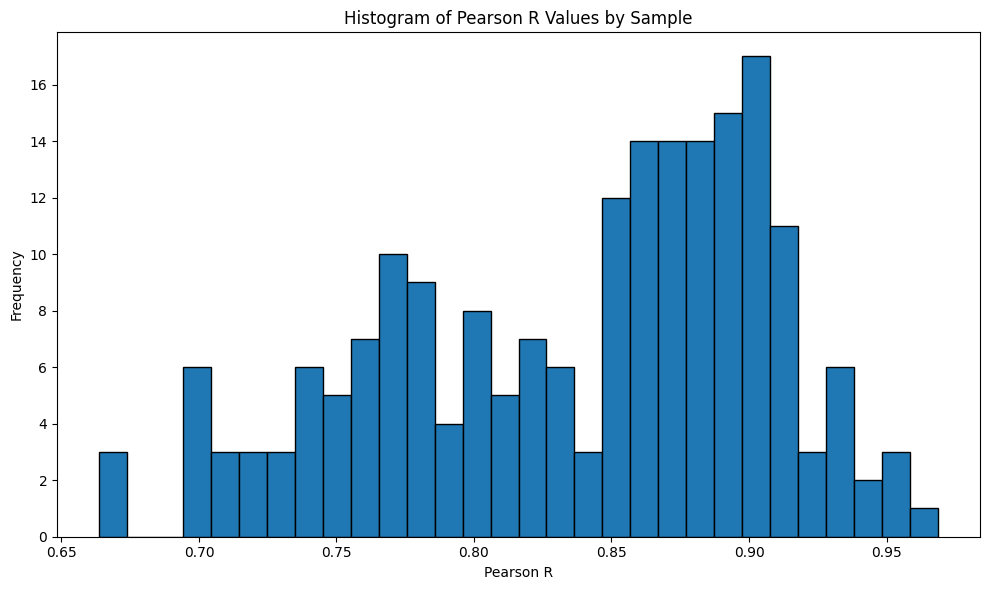

In [22]:
# Assuming 'grouped_by_sample' contains the 'pearson_r' column
plt.figure(figsize=(10, 6))

# Plotting the histogram
plt.hist(grouped_by_sample['pearson_r'], bins=30, edgecolor='black')

# Adding labels and title
plt.title("Histogram of Pearson R Values by Sample")
plt.xlabel("Pearson R")
plt.ylabel("Frequency")

# Show the plot
plt.tight_layout()
plt.show()


#### Variant prediction plotting

In [3]:
import pandas as pd

# Load the file
df = pd.read_csv("/home/mbrannon/tmp/variant_pred_new_8_1.tsv", sep="\t")

# Rename the columns
df = df.rename(columns={
    "predicted_counts": "predicted_lfc",
    "target_counts": "target_lfc"
})

# (Optional) Save the updated DataFrame back to file
df.to_csv("/home/mbrannon/tmp/variant_pred_new_8_1_renamed.tsv", sep="\t", index=False)


In [ ]:
#variants

/tmp/ipykernel_13176/2232351966.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


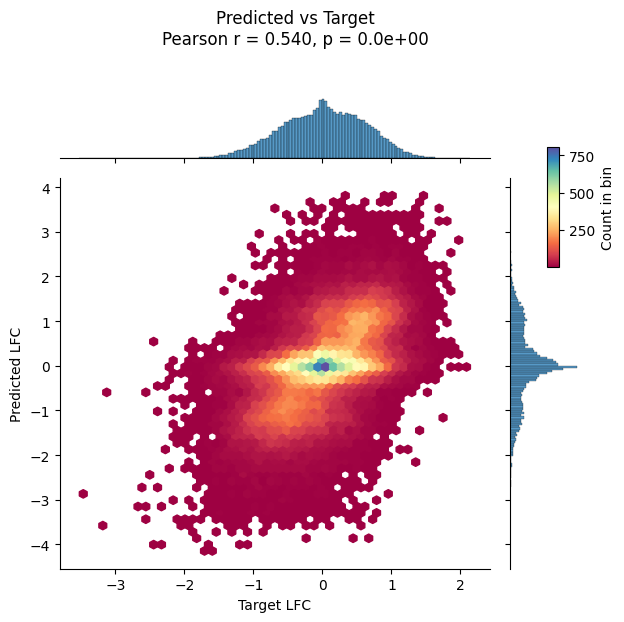

In [13]:

df_old = pd.read_table('/home/mbrannon/tmp/variant_pred_new_8_1.tsv')

# Pearson correlation
r, p = pearsonr(df_old["predicted_lfc"], df_old["target_lfc"])

# Create joint hex plot with more bins, custom color palette, and mincnt
plot = sns.jointplot(
    x="predicted_lfc",
    y="target_lfc",
    data=df_old,
    kind='hex',
    cmap="Spectral",  # Change color map for more range
    height=6,
    gridsize=50,  # More bins for finer detail
    mincnt=1  # Ensures bins with counts are shown, even if sparse
)

# Add title with Pearson r and p-value
plot.fig.suptitle(f"Predicted vs Target\nPearson r = {r:.3f}, p = {p:.1e}", y=1.03)

# Adjust axes labels
plot.set_axis_labels("Target LFC", "Predicted LFC")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])  # right side
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()


In [10]:
df

,sample_id,chr,pos,ref,alt,predicted_lfc,target_lfc
0,AG6445,chr7,55110464,C,T,0.580678,-0.566254
1,AG58832,chr12,17194845,G,A,-0.420049,-0.399059
2,AG72438,chr2,219526450,G,A,-0.350937,0.399059
3,AG96366,chr9,105447930,A,C,-0.397076,-0.462510
4,AG96467,chr5,123438538,C,A,-1.068937,-1.210389
...,...,...,...,...,...,...,...
49523707,AG81802,chr12,95918907,C,A,0.450008,0.010263
49523708,AG68557,chr8,130675757,A,G,-0.246546,-0.658655
49523709,AG71488,chr9,101533486,C,T,0.638739,0.444798
49523710,AG6245,chr2,128190320,T,C,0.011512,0.000000


/tmp/ipykernel_13176/225601220.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


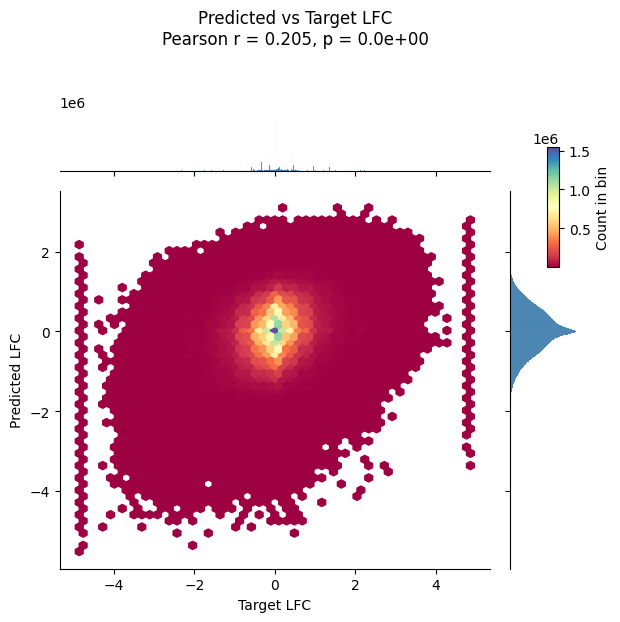

In [6]:
df = pd.read_csv("/home/mbrannon/tmp/variant_preds/variant_predictions_JUL28_3_a100_clip_density.bed", sep="\t")

# Pearson correlation
r, p = pearsonr(df["predicted_lfc"], df["target_lfc"])

# Plot using seaborn jointplot with hex bins
plot = sns.jointplot(
    x="target_lfc",
    y="predicted_lfc",
    data=df,
    kind='hex',
    cmap="Spectral",
    height=6,
    gridsize=50,
    mincnt=1
)

# Add title with Pearson r and p-value
plot.fig.suptitle(f"Predicted vs Target LFC\nPearson r = {r:.3f}, p = {p:.1e}", y=1.03)

# Axis labels
plot.set_axis_labels("Target LFC", "Predicted LFC")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()


In [14]:
df = pd.read_csv("/home/mbrannon/tmp/variant_preds/variant_predictions_JUL28_3_a100_clip_density.bed", sep="\t")

# Group by sample_id and compute Pearson r for each group
correlation_df = df.groupby("sample_id").apply(
    lambda g: pd.Series(pearsonr(g["predicted_lfc"], g["target_lfc"]), index=["r", "p"])
).reset_index()

print(correlation_df.head())


  sample_id         r             p
0   AG10031  0.090159  2.835315e-07
1   AG10032  0.115224  6.299985e-14
2   AG10033  0.096327  4.823215e-10
3   AG10034  0.060749  7.357052e-04
4   AG10036  0.122192  2.388020e-17


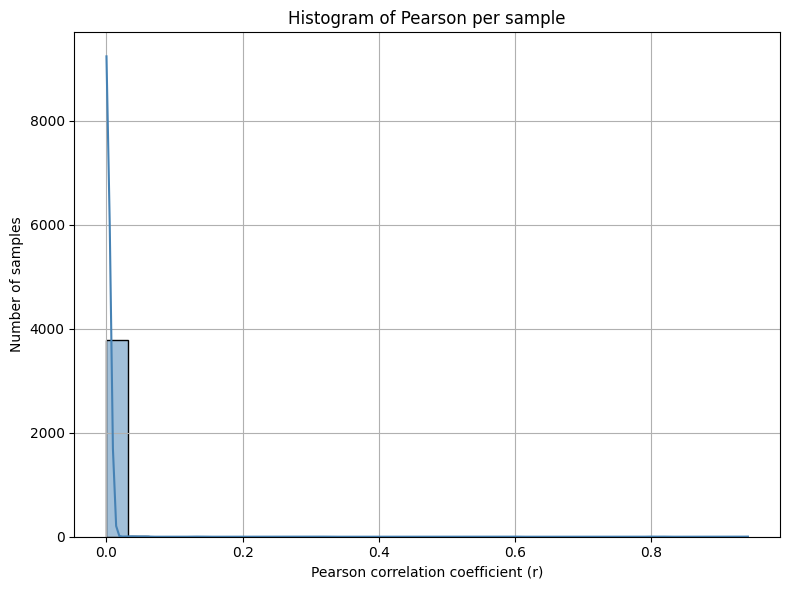

In [18]:
df = pd.read_csv("/home/mbrannon/tmp/variant_preds/variant_predictions_JUL28_3_a100_clip_density.bed", sep="\t")

# Compute Pearson r per sample_id
correlation_df = df.groupby("sample_id").apply(
    lambda g: pd.Series(pearsonr(g["predicted_lfc"], g["target_lfc"]), index=["r", "p"])
).reset_index()

# Plot histogram of Pearson r-values
plt.figure(figsize=(8, 6))
sns.histplot(correlation_df["p"], bins=30, kde=True, color="steelblue")

plt.title("Histogram of Pearson per sample")
plt.xlabel("Pearson correlation coefficient (r)")
plt.ylabel("Number of samples")
plt.grid(True)
plt.tight_layout()
plt.show()


#### shape

In [ ]:
#run shap using run_shap.sh script
#results is np file which is real_scores = (_X * attrs_stack).sum(axis=1)

In [28]:
import numpy as np

# For a single array saved in .npy format

real_scores = np.load('/home/mbrannon/tmp/shapAG95390_50top_real_score.npy')
X_attr = np.load('/home/mbrannon/tmp/shapAG95390_50top_attr.npy')

In [29]:
X_attr.shape

(17510, 4, 1344)

In [30]:
real_scores.shape

(17510, 1344)

In [31]:
n = real_scores.shape[0]
k = 10
chunk_size = (n + k - 1) // k

seqlet_list = []
for i in range(k):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, n)
    if start >= end:
        break
    print(f"Processing chunk {i+1}/{k} with rows {start}:{end}")
    
    try:
        real_scores_tensor = torch.tensor(real_scores[start:end], dtype=torch.float32)
        seq_part = tfmodisco_seqlets(real_scores_tensor, window_size=8)
        seqlet_list.append(seq_part)
    except ZeroDivisionError:
        print(f"Skipping chunk {i+1} (no valid positive/negative values)")


Processing chunk 1/10 with rows 0:1751
Processing chunk 2/10 with rows 1751:3502
Processing chunk 3/10 with rows 3502:5253
Processing chunk 4/10 with rows 5253:7004
Processing chunk 5/10 with rows 7004:8755
Processing chunk 6/10 with rows 8755:10506
Processing chunk 7/10 with rows 10506:12257
Processing chunk 8/10 with rows 12257:14008
Processing chunk 9/10 with rows 14008:15759
Processing chunk 10/10 with rows 15759:17510


In [32]:
tfseqlets = pd.concat(seqlet_list, ignore_index=True)

In [33]:
seqlets = recursive_seqlets(real_scores, additional_flanks=3, threshold=0.0001, max_seqlet_len=8)


In [34]:
plt.figure(figsize=(12, 3))
ax = plt.subplot(111)
plot_logo(X_attr[2], ax=ax, start=600, end=800, annotations=tfseqlets, score_key="attribution")

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attribution")
plt.title("DeepLIFT/SHAP of Marginalization")
plt.show()

ValueError: Image size of 1016x83435 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1200x300 with 1 Axes>

In [35]:
meme_file = '/home/jvierstra/public_html/projects/motif-clustering-v2.1beta/all.dbs.meme'


In [36]:
motifs = read_meme(meme_file)
motif_idxs, motif_pvalues = annotate_seqlets(X_attr, tfseqlets, motifs)

In [37]:
motifs = read_meme(meme_file)
motif_names = np.array(list(motifs.keys()))


y = count_annotations((tfseqlets['example_idx'], motif_idxs[:, 0]))


In [38]:
# If y is sparse and fits in memory as dense
motif_counts = y.to_dense().sum(dim=0)  # sum over rows (examples) → shape: [num_motifs]


In [39]:
motif_count_list = [(count.item(), idx) for idx, count in enumerate(motif_counts)]
# Optionally sort by count descending
motif_count_list.sort(reverse=True)


In [40]:
motifs = read_meme(meme_file)
index_to_name = [k for k, v in motifs.items()]
records = []
for count, idx in motif_count_list:
    name = index_to_name[idx]
    records.append((count, idx, name))


In [41]:


# records: list of tuples (count, idx, name)
motif_counts_df = pd.DataFrame(records, columns=["count", "motif_index", "motif_name"])

# Optional: sort by count descending
motif_counts_df  = motif_counts_df.sort_values(by="count", ascending=False).reset_index(drop=True)



In [42]:
motif_counts_df

,count,motif_index,motif_name
0,73351,27,M00243_2.00
1,66339,30,M00246_2.00
2,29060,29,M00245_2.00
3,764,2284,M05284_2.00
4,550,65,M00281_2.00
...,...,...,...
4271,0,2846,M05849_2.00
4272,0,2845,M05848_2.00
4273,0,2844,M05847_2.00
4274,0,2843,M05846_2.00


In [43]:
# Load your DataFrame (already defined as `df`)
# Ensure motif_name is string
motif_counts_df["motif_name"] = motif_counts_df["motif_name"].astype(str)

# Load metadata
metadata = pd.read_csv(
    "/home/jvierstra/public_html/projects/motif-clustering-v2.1beta/metadata.tsv",
    sep="\t",
    dtype=str
)

# Merge on motif_name (df) and motif_id (metadata)
merged_df = motif_counts_df.merge(metadata, how="left", left_on="motif_name", right_on="motif_id")


In [44]:
merged_df.head(20)


,count,motif_index,motif_name,motif_id,cluster,source_id,tf_name,family_name,motif_type,PMID
0,73351,27,M00243_2.00,M00243_2.00,AC0441,WT1_F392L,WT1,C2H2 ZF,PBM,27013732
1,66339,30,M00246_2.00,M00246_2.00,AC0441,WT1_R366L,WT1,C2H2 ZF,PBM,27013732
2,29060,29,M00245_2.00,M00245_2.00,AC0441,WT1_R366C,WT1,C2H2 ZF,PBM,27013732
3,764,2284,M05284_2.00,M05284_2.00,AC0440,IRX1_eDBD_Methyl-HT-SELEX,IRX1,Homeodomain,SELEX,28473536
4,550,65,M00281_2.00,M00281_2.00,AC0441,PHOX2B_R141Q,PHOX2B,Homeodomain,PBM,27013732
5,137,4275,M10814_2.00,M10814_2.00,AC0440,V$PAX4_04,PAX4,"Homeodomain,Paired box",Transfac,16381825
6,2,3006,M07681_2.00,M07681_2.00,AC0472,ZNF17.RCADE.ReprocessedData,ZNF17,C2H2 ZF,ChIP-seq+ChIP-exo,29146583
7,1,108,M00324_2.00,M00324_2.00,AC0441,NKX2-5_T178M,NKX2-5,Homeodomain,PBM,27013732
8,0,1431,M04431_2.00,M04431_2.00,AC0108,KLF12_FL_Methyl-HT-SELEX_1,KLF12,C2H2 ZF,SELEX,28473536
9,0,1425,M04425_2.00,M04425_2.00,AC0210,BCL6_eDBD_HT-SELEX_2,BCL6,C2H2 ZF,SELEX,28473536


In [45]:
df_pos = seqlets[seqlets["attribution"] > 0].reset_index(drop=True)


In [46]:
seqlet_annotations['example_idx'] = [motif_names[idx] for idx in motif_idxs]

plt.figure(figsize=(12, 2))
ax = plt.subplot(111)
plot_logo(X_attr[1], ax=ax, start=925, end=1075, annotations=seqlet_annotations, score_key='attribution', ylim=0.15)
plt.ylim(-0.05, 0.15)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attribution")
plt.title("DeepLIFT/SHAP of Marginalization")
plt.show()

NameError: name 'seqlet_annotations' is not defined

### predict mouse

In [196]:
bed_file = '/net/seq/data2/projects/ENCODE4Plus/hotspot3/mouse/output/AG10359/fdr0.001/AG10359.peaks.fdr0.001.bed.gz'
pattern = '/net/seq/data2/projects/ENCODE4Plus/hotspot3/mouse/output/AG10359/AG10359.normalized_density.bw'
fh = pbw.open(pattern)

bed_df = pd.read_csv(bed_file, sep="\t", usecols=[0, 1, 2])

In [48]:
bed_df

,#chr,start,end
0,chr1,3514986,3515244
1,chr1,4332573,4332784
2,chr1,4479624,4479899
3,chr1,4571729,4572039
4,chr1,4602318,4602672
...,...,...,...
86899,chrX,169714374,169714592
86900,chrX,169879469,169879717
86901,chrX,169906307,169906568
86902,chrX,169918462,169918683


In [ ]:
# Make list of widened intervals
fh = pbw.open(pattern)

intervals = []
dens = []
for _, row in bed_df.iterrows():
    reglen = ((row["end"]) - (row["start"]))//2
    mid = row["start"]+reglen
    interval = GenomicInterval(row["#chr"], mid, mid).widen(672)
    density = fh.values(interval.chrom, mid, mid+1, numpy=True)[0]
    dens.append(density)
    intervals.append(interval)

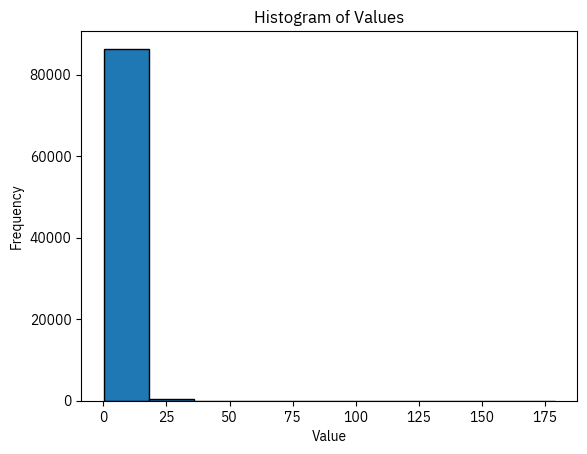

In [ ]:
plt.hist(dens, bins=10, edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Values")
plt.show()

In [ ]:
df['obs_log'] = np.log(df['obs_density'] + 1e-6)   # natural log
df['pred_log'] = np.log(df['pred_density'] + 1e-6)

df.head()


,obs_density,pred_density,obs_log,pred_log
0,1.127811,0.231155,0.120280,-1.464665
1,0.375937,1.044077,-0.978331,0.043134
2,0.433774,0.228146,-0.835230,-1.477765
3,0.462692,0.849128,-0.770692,-0.163544
4,0.173509,0.422510,-1.751518,-0.861539


In [ ]:
# Calculate correlations
pearson_density_r, _ = pearsonr(df['obs_log'], df["pred_log"])

ValueError: Could not interpret value `obs_log` for `x`. An entry with this name does not appear in `data`.

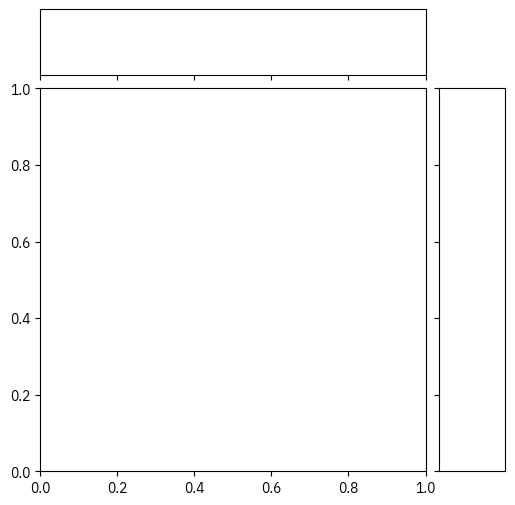

In [361]:
# Create joint hex plot

# Apply log transformation (handles 0s safely)

plot = sns.jointplot(
    x="obs_log", 
    y="pred_log", 
    data=df,
    kind='hex',
    cmap = 'Greens',
    marginal_kws=dict(color = 'Green', kde=True),
    height=6,
    gridsize=50,
    mincnt=1
)

plot.ax_joint.set_xlim(-5, 5)   # adjust to your data range
plot.ax_joint.set_ylim(-5, 5)

# Add title with Pearson r
plot.fig.suptitle(f"Predicted vs Obs\nPearson = {pearson_density_r:.3f}", y=1.03)

# Adjust axes labels
plot.set_axis_labels("Log Observed density", "Log Predicted density")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()
